# 4. Exploracao dos resultados da modelagem

Este notebook traduz os resultados do modelo para decisao institucional.
Objetivo: transformar previsoes em prioridades de acao para a Reitoria, Pro-Reitorias e coordenacoes.

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

with open('artefatos/inferencia_modelagem.pkl', 'rb') as f:
    artefato = pickle.load(f)

pipe_melhor = artefato['pipeline_melhor']
melhor_modelo = artefato.get('modelo_nome', 'Modelo salvo')
X_test = artefato['X_test'].copy()
y_test = artefato['y_test'].copy()

# Reconstroi base analitica com contexto academico sem reestimar modelos
base_modelo = pd.read_csv('dados/df_modelo_tratado.csv')
analise_df = base_modelo.loc[X_test.index, [
    'id_discente', 'id_disciplina', 'nome_componete_curricular',
    'sigla_departamento', 'sigla_centro', 'area_conhecimento',
    'forma_ingresso', 'faixa_renda_familiar', 'raca_declarada',
    'sexo', 'idade', 'primeiro_periodo', 'target'
]].copy()

# Inferencia com modelo ja treinado/salvo
p_sucesso = pipe_melhor.predict_proba(X_test)[:, 1]
y_pred = pipe_melhor.predict(X_test)
analise_df['pred'] = y_pred
analise_df['p_sucesso'] = p_sucesso
analise_df['p_risco_insucesso'] = 1.0 - p_sucesso
analise_df['acerto'] = (analise_df['pred'] == analise_df['target']).astype(int)
analise_df['faixa_risco'] = pd.qcut(
    analise_df['p_risco_insucesso'],
    q=4,
    labels=['baixo', 'moderado baixo', 'moderado alto', 'alto'],
    duplicates='drop'
)

print(f"Modelo carregado: {melhor_modelo}")
print(f"Base analitica pronta: {analise_df.shape[0]:,} linhas")


Modelo carregado: XGBoost
Base analitica pronta: 25,153 linhas


## 4. Quais disciplinas oferecem maior risco?

Leitura sugerida para o Reitor:
- priorizar disciplinas com risco alto **e** volume relevante;
- observar taxa real de insucesso para validar coerencia do modelo;
- usar esse ranking para acao preventiva (monitoria, reforco, ajustes pedagogicos).

,n,risco_medio,taxa_insucesso_real
nome_componete_curricular,,,
NOÇÕES DE PESQUISA,40,0.642081,0.525000
REGISTROS EM SAÚDE,37,0.615201,0.486486
SAÚDE E SEGURANÇA NO TRABALHO,47,0.588369,0.617021
ORGANIZAÇÃO DO PROCESSO DE TRABALHO EM REGISTROS E INFORMAÇÕES EM SAÚDE,44,0.583728,0.568182
ANATOMIA E FISIOLOGIA APLICADAS À NUTRIÇÃO,91,0.579655,0.362637
ÉTICA PROFISSIONAL E RELAÇÕES INTERPESSOAIS,51,0.576947,0.333333
INFORMÁTICA EM SAÚDE II,31,0.570976,0.580645
REPRODUÇÃO E LARVICULTURA DE PEIXES,34,0.568930,0.352941
EPIDEMIOLOGIA,31,0.567609,0.354839


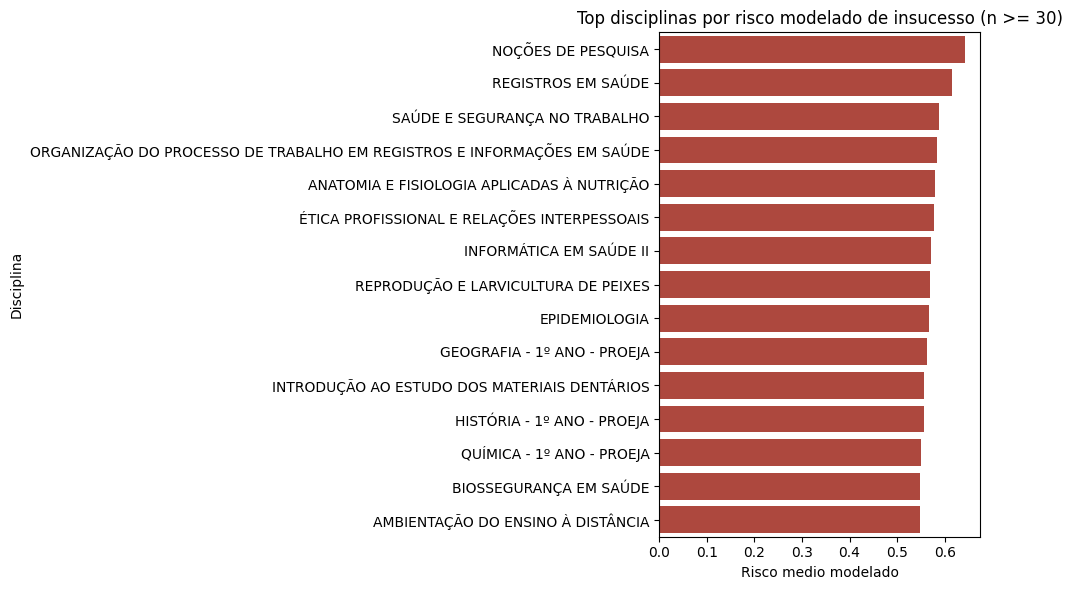

In [6]:
risco_disc = (
    analise_df.groupby('nome_componete_curricular', observed=True)
    .agg(
        n=('target', 'count'),
        risco_medio=('p_risco_insucesso', 'mean'),
        taxa_insucesso_real=('target', lambda s: 1 - s.mean())
    )
    .query('n >= 30')
    .sort_values(['risco_medio', 'n'], ascending=[False, False])
)

top_disc = risco_disc.head(15)
display(top_disc)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_disc.reset_index(), y='nome_componete_curricular', x='risco_medio', color='#C0392B')
plt.title('Top disciplinas por risco modelado de insucesso (n >= 30)')
plt.xlabel('Risco medio modelado')
plt.ylabel('Disciplina')
plt.tight_layout()
plt.show()

## 5. Perfis de estudantes com maior prioridade

Cruzamos o risco com atributos de perfil para identificar grupos que merecem atencao adicional.

In [7]:
analise_df['faixa_idade'] = pd.cut(
    analise_df['idade'],
    bins=[0, 17, 20, 24, 29, 100],
    labels=['<=17', '18-20', '21-24', '25-29', '30+']
)

perfil_cols = ['sexo', 'raca_declarada', 'faixa_renda_familiar', 'forma_ingresso', 'primeiro_periodo', 'faixa_idade']

def resumo_perfil(col):
    return (
        analise_df.groupby(col, observed=True)
        .agg(
            n=('target', 'count'),
            risco_medio=('p_risco_insucesso', 'mean'),
            taxa_insucesso_real=('target', lambda s: 1 - s.mean())
        )
        .query('n >= 30')
        .sort_values('risco_medio', ascending=False)
    )

resumos_perfil = {c: resumo_perfil(c) for c in perfil_cols}
for c in perfil_cols:
    print('\n' + '='*80)
    print(f'Perfil: {c}')
    display(resumos_perfil[c].head(10))


Perfil: sexo


,n,risco_medio,taxa_insucesso_real
sexo,,,
M,10958,0.305493,0.236722
F,14190,0.280585,0.204863



Perfil: raca_declarada


,n,risco_medio,taxa_insucesso_real
raca_declarada,,,
Nao_informado,2706,0.364807,0.262749
Outra,714,0.354692,0.278711
Negra,16235,0.284572,0.214660
Branca,5498,0.267308,0.201346



Perfil: faixa_renda_familiar


...

,n,risco_medio,taxa_insucesso_real
forma_ingresso,,,
PROCESSO SELETIVO,24961,0.292506,0.219462
outros,192,0.150274,0.125000



Perfil: primeiro_periodo


,n,risco_medio,taxa_insucesso_real
primeiro_periodo,,,
1,13860,0.367160,0.285931
0,11293,0.198465,0.136279



Perfil: faixa_idade


,n,risco_medio,taxa_insucesso_real
faixa_idade,,,
30+,3880,0.341184,0.255412
25-29,3014,0.335210,0.238222
21-24,6658,0.322774,0.225593
18-20,6352,0.290370,0.228747
<=17,5249,0.190995,0.159649


## 6. Mapa de risco por centro e area

Visao macro para a alta gestao localizar concentracao de risco na estrutura institucional.

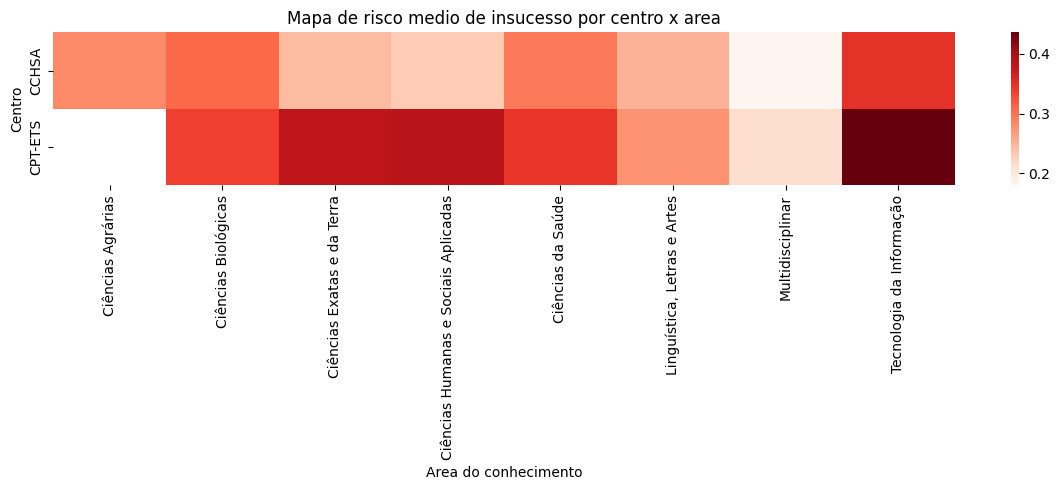

In [10]:
heat = (
    analise_df.groupby(['sigla_centro', 'area_conhecimento'], observed=True)
    .agg(risco_medio=('p_risco_insucesso', 'mean'), n=('target', 'count'))
    .query('n >= 20')
    .reset_index()
)

pivot_heat = heat.pivot(index='sigla_centro', columns='area_conhecimento', values='risco_medio')

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_heat, cmap='Reds', annot=False)
plt.title('Mapa de risco medio de insucesso por centro x area')
plt.xlabel('Area do conhecimento')
plt.ylabel('Centro')
plt.tight_layout()
plt.show()

## 7. Painel executivo (mensagens para apresentacao)

Abaixo, um resumo textual pronto para comunicacao com a Reitoria.

In [11]:
kpi_risco_alto = (analise_df['faixa_risco'] == 'alto').mean()
tx_insucesso_real = 1 - analise_df['target'].mean()
top5_disc = top_disc.head(5).index.tolist()

print('RESUMO EXECUTIVO PARA A REITORIA')
print('-' * 70)
print(f'Modelo selecionado: {melhor_modelo}')
print(f'Taxa real de insucesso no conjunto avaliado: {tx_insucesso_real:.2%}')
print(f'Percentual de estudantes na faixa de risco alto: {kpi_risco_alto:.2%}')
print('\nDisciplinas com maior risco medio (prioridade imediata):')
for d in top5_disc:
    print(f' - {d}')

print('\nRecomendacoes de curto prazo:')
print('1) Plano de intervencao para disciplinas de maior risco e alto volume.')
print('2) Busca ativa de estudantes em risco alto no primeiro periodo.')
print('3) Monitoramento mensal por centro/area com os mesmos KPIs deste notebook.')

RESUMO EXECUTIVO PARA A REITORIA
----------------------------------------------------------------------
Modelo selecionado: XGBoost
Taxa real de insucesso no conjunto avaliado: 21.87%
Percentual de estudantes na faixa de risco alto: 25.00%

Disciplinas com maior risco medio (prioridade imediata):
 - NOÇÕES DE PESQUISA
 - REGISTROS EM SAÚDE
 - SAÚDE E SEGURANÇA NO TRABALHO
 - ORGANIZAÇÃO DO PROCESSO DE TRABALHO EM REGISTROS E INFORMAÇÕES EM SAÚDE
 - ANATOMIA E FISIOLOGIA APLICADAS À NUTRIÇÃO

Recomendacoes de curto prazo:
1) Plano de intervencao para disciplinas de maior risco e alto volume.
2) Busca ativa de estudantes em risco alto no primeiro periodo.
3) Monitoramento mensal por centro/area com os mesmos KPIs deste notebook.


## 8. Exportacao opcional da base de risco

Use esta base para dashboard e acompanhamento continuo.

In [12]:
analise_df.to_csv('dados/saida_analise_risco_modelo.csv', index=False)
# print('Arquivo exportado: dados/saida_analise_risco_modelo.csv')